#INFORMACIÓN GENERAL


UNIVERSIDAD NACIONAL DE SAN ANTONIO ABAD DEL CUSCO

INGENIERÍA INFORMÁTICA Y DE SISTEMAS

INTELIGENCIA ARTIFICIAL

LABORATORIO 04: BÚSQUEDA A*


#BÚSQUEDA A*


A la forma más ampliamente conocida de la búsqueda primero el mejor se le llama búsqueda A* (pronunciada «búsqueda A-estrella»). 

Evalúa los nodos combinando g(n), el coste para alcanzar el nodo, y h(n), el coste de ir al nodo objetivo está dado por la función de evaluación:

$f (n) = g(n) + h(n)$

Ya que la g(n) nos da el coste del camino desde el nodo inicio al nodo n, y la heurística h(n) el coste estimado del camino más barato desde n al objetivo, tenemos:

$f(n)$ coste más barato estimado de la solución a través de n.



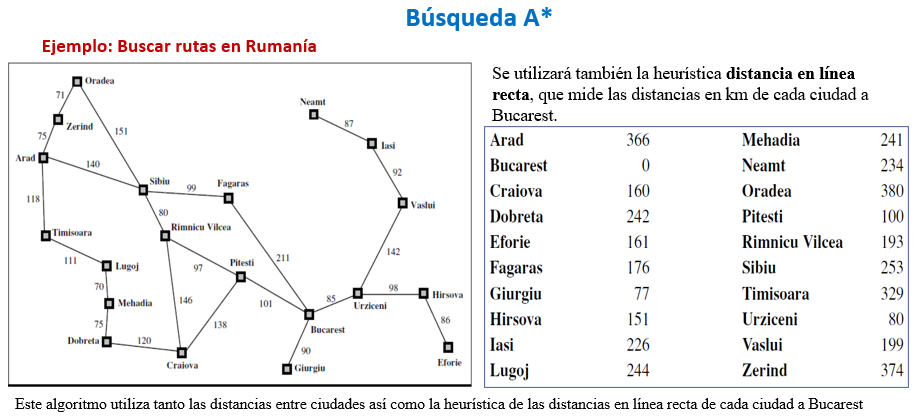

##Clases de un motor de búsqueda de soluciones

###Clase Acción

In [1]:
#Clase Acción
class Accion:
  def __init__(self, nombre):
    self.nombre = nombre

  def __str__(self):
    return self.nombre

###Clase Estado

In [2]:
#Clase Estado
class Estado:
  def __init__(self, nombre, acciones):
    self.nombre = nombre
    self.acciones = acciones

  def __str__(self):
    return self.nombre  

###Clase Problema

In [3]:
#Clase Problema. 
class Problema:
  def __init__(self, nombre, estado_inicial, estados_objetivos, acciones, costes=None, heuristica=None):
    self.nombre = nombre
    self.estado_inicial = estado_inicial
    self.estados_objetivos = estados_objetivos
    self.acciones = acciones
    self.costes = costes
    self.heuristica = heuristica
    self.infinito = 999999
    
  def __str__(self):
    msg = "Estado Inicial: {0} -> Objetivos: {1}"    
    return msg.format(self.estado_inicial.nombre,self.estados_objetivos)

  # -- Determina si se alcanzó el objetivo
  def es_objetivo(self, estado):
    return estado in self.estados_objetivos

  # -- Determina el estado al que se llega del estado actual en base a la acción
  def siguienteEstado(self, estado, accion):    
    # -- Recuperar diccionario de posibles acciones que se pueden realizar del estado actual    
    acciones_estado = self.acciones[estado.nombre]    
    # -- Recupera y devuelve el nuevo estado alcanzado después de ejecutar la acción
    return acciones_estado[accion.nombre]

  # -- Determina el costo de una acción de un estado
  def coste_accion(self, estado, accion):
    if estado.nombre not in self.costes.keys():
      return self.infinito
    costes_estado = self.costes[estado.nombre]
    if accion.nombre not in costes_estado.keys():
      return self.infinito
    return costes_estado[accion.nombre]

  # -- Determina el valor de la funcion heuristica de un estado
  def funcionHeuristica(self, estado):
    valor = 0
    if estado.nombre not in self.heuristica.keys():
      valor = self.infinito
    else:
      # -- Recuperar el valor de la heuristica
      valor = self.heuristica[estado.nombre]
    return valor

  # -- Determina el costo del camino desde la raiz a un nodo dado
  def coste_camino(self, nodo):
    total = 0
    while nodo.padre:
      total += self.coste_accion(nodo.padre.estado, nodo.accion)      
      nodo = nodo.padre
    return total


###Clase Nodo

In [4]:
#Clase Nodo
class Nodo:
  def __init__(self, estado, accion=None, acciones=None, padre=None):    
    self.estado = estado # -- Estado al que corresponde el nodo
    self.accion = accion # -- Acción mediante la cuál se llegó a este nodo
    self.acciones = acciones # -- Acciones posibles a realizar a partir de este nodo para llegar a los hijos
    self.padre = padre
    self.hijos = [] # -- Lista de nodos hijo (objetos) del nodo actual
    self.coste = 0

  def __str__(self):
    return self.estado.nombre  
  


##Aplicación: Viajes en ciudades

### Clase ViajesCiudades


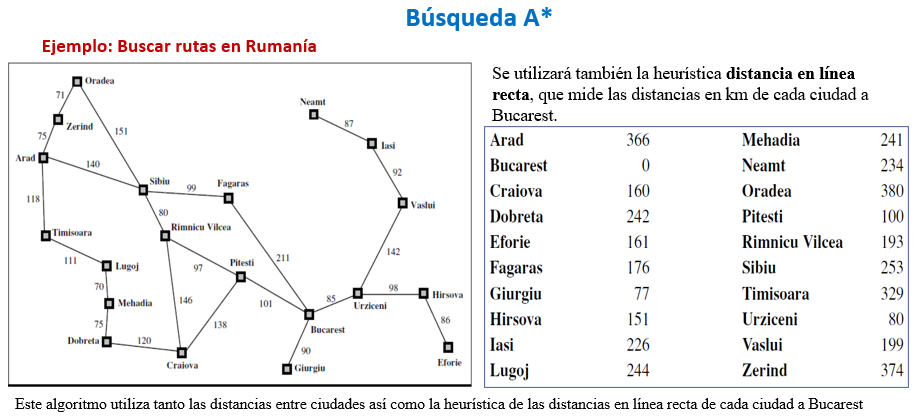

In [11]:
#Clase ViajesCiudades
class ViajesCiudades:
  
  def __init__(self):
    # -- Nombre de la clase
    self.nombre = 'Viajes por ciudades'
    
    # -- Definición de acciones
    accN = Accion ('N')
    accS = Accion ('S')
    accE = Accion ('E')
    accO = Accion ('O')
    accNE = Accion ('NE')
    accNO = Accion ('NO')
    accSE = Accion ('SE')
    accSO = Accion ('SO')    

    # -- Definción de estados
    oradea = Estado('Oradea', [accSE, accSO])
    zerind = Estado ('Zerind', [accNO, accSE])
    arad = Estado('Arad', [accNO, accS, accO])
    timisoara = Estado('Timisoara', [accN, accO])
    lugoj = Estado('Lugoj', [accE, accS])
    mehadia = Estado('Mehadia', [accN, accS])
    dobreta = Estado('Dobreta', [accN, accO])
    craiova = Estado('Craiova', [accE, accN, accNO])
    sibiu = Estado('Sibiu', [accE, accNE, accO, accSO])
    fagaras = Estado('Fagaras', [accE, accSO])
    rimnicuVilcea = Estado('RimnicuVilcea', [accNE, accS, accSO])
    pitesti = Estado('Pitesti', [accNE, accSE, accO])
    bucarest = Estado('Bucarest', [accNE, accE, accSE, accO])
    giurgiu = Estado('Giurgiu', [accNO])
    urziceni = Estado('Urziceni', [accE, accO, accNO])
    hirsova = Estado('Hirsova', [accE, accSO])
    eforie = Estado('Eforie', [accNE])
    vaslui = Estado('Vaslui', [accSE, accNE])
    iasi = Estado('Iasi', [accSO, accNE])
    neamt = Estado('Neamt', [accSO])
  
    # -- Definición de viajes
    viajes = {'Oradea': {'SE': zerind,
                         'SO': sibiu},
              'Zerind': {'NO': oradea,
                         'SE': arad},
              'Arad' : {'NO': zerind,
                        'S': timisoara,
                        'O': sibiu},              
              'Timisoara' : {'N': arad,
                             'O': lugoj},
              'Lugoj' : {'E': timisoara,                         
                         'S': mehadia},
              'Mehadia': {'N': lugoj,
                          'S': dobreta},
              'Dobreta': {'N': mehadia,
                          'O': craiova},
              'Craiova': {'E': dobreta,
                          'N': rimnicuVilcea,
                          'NO': pitesti},
              'Sibiu': {'E': arad,
                        'NE': oradea,
                        'O': fagaras,
                        'SO': rimnicuVilcea},
              'Fagaras': {'E': sibiu,                          
                          'SO': bucarest},
              'RimnicuVilcea': {'NE': sibiu,
                                'S': craiova,
                                'SO': pitesti},
              'Pitesti': {'NE': rimnicuVilcea,
                          'SO': craiova,
                          'O': bucarest},
              'Bucarest': {'NE': fagaras,
                           'E': pitesti,
                           'SE': giurgiu,
                           'O': urziceni},
              'Giurgiu': {'NO': bucarest},
              'Urziceni': {'E': bucarest,
                           'O': hirsova,
                           'NO': vaslui},
              'Hirsova': {'E': urziceni,                      
                          'SO': eforie},
              'Eforie': {'NE': hirsova},
              'Vaslui': {'SE': urziceni,
                         'NE': iasi},
              'Iasi': {'SO': vaslui,
                       'NE': neamt},              
              'Neamt': {'SO': iasi}
            }    

    # -- Definición de costos
    costos = {'Oradea': {'SE': 71,
                         'SO': 151},
              'Zerind': {'NO': 71,
                         'SE': 75},
              'Arad' : {'NO': 75,
                        'S': 118,
                        'O': 140},              
              'Timisoara' : {'N': 118,
                             'O': 111},
              'Lugoj' : {'E': 111,                         
                         'S': 70},
              'Mehadia': {'N': 70,
                          'S': 75},
              'Dobreta': {'N': 75,
                          'O': 120},
              'Craiova': {'E': 120,
                          'N': 146,
                          'NO': 138},
              'Sibiu': {'E': 140,
                        'NE': 151,
                        'O': 99,
                        'SO': 80},
              'Fagaras': {'E': 99,                          
                          'SO': 211},
              'RimnicuVilcea': {'NE': 80,
                                'S': 146,
                                'SO': 97},
              'Pitesti': {'NE': 97,
                          'SO': 138,
                          'O': 101},
              'Bucarest': {'NE': 211,
                           'E': 101,
                           'SE': 90,
                           'O': 85},
              'Giurgiu': {'NO': 90},
              'Urziceni': {'E': 85,
                           'O': 98,
                           'NO': 142},
              'Hirsova': {'E': 98,                      
                          'SO': 86},
              'Eforie': {'NE': 86},
              'Vaslui': {'SE': 142,
                         'NE': 92},
              'Iasi': {'SO': 92,
                       'NE': 87},              
              'Neamt': {'SO': 87}
            }    

    # -- Definición de distancias en línea recta (heurística)
    heuristica = {'Arad': 366,
                  'Bucarest': 0,
                  'Craiova' : 160,              
                  'Dobreta' : 242,
                  'Eforie' : 161,
                  'Fagaras': 176,
                  'Giurgiu': 77,
                  'Hirsova': 151,
                  'Iasi': 226,
                  'Lugoj': 244,
                  'Mehadia': 241,
                  'Neamt': 234,
                  'Oradea': 380,
                  'Pitesti': 100,
                  'RimnicuVilcea': 193,
                  'Sibiu': 253,
                  'Timisoara': 329,
                  'Urziceni': 80,
                  'Vaslui': 199,              
                  'Zerind': 374
            }    


    # -- Definir el atributo lista de estados en el contexto del problema
    self.estados = [oradea, zerind, arad, timisoara, lugoj, mehadia, dobreta,
                    craiova, sibiu, fagaras, rimnicuVilcea, pitesti, bucarest,
                    giurgiu, urziceni, hirsova, eforie, vaslui, iasi, neamt]

    # -- Definir el atributo de los posibles viajes de una ciudad a otras
    self.viajes = viajes
    # -- Definir el atributo de los costos (en km) de los posibles viajes 
    self.costos = costos    
    # -- Definir la heurística, distancia en línea recta (en km) de cada ciudad al destino
    self.heuristica = heuristica    

  def __str__(self):
    return self.nombre

  def crea_nodo_raiz(self, problema):
    # -- Recupera el estado inicial para en función a éste configurar la raiz
    estado_raiz = problema.estado_inicial
    # -- Determina las acciones de este nodo
    acciones_raiz = {}
    if estado_raiz.nombre in problema.acciones.keys():
      acciones_raiz = problema.acciones[estado_raiz.nombre]
    # -- Genera el nodo raiz
    raiz = Nodo(estado_raiz, None, acciones_raiz, None)    
    # -- El nodo raiz tiene costo cero más la heurística
    raiz.coste = problema.funcionHeuristica(estado_raiz)    
    return raiz

  def crea_nodo_hijo (self, problema, padre, accion):
    # -- Recupera el estado que resulta de ejecutar la acción sobre el nodo padre
    nuevo_estado = problema.siguienteEstado(padre.estado, accion)
    # -- Recuperar las acciones del nuevo estado
    acciones_nuevo = {}
    if nuevo_estado.nombre in problema.acciones.keys():
      acciones_nuevo = problema.acciones[nuevo_estado.nombre]
    # -- Genera un nuevo nodo para el nuevo estado con sus respectivas acciones
    hijo = Nodo(nuevo_estado, accion, acciones_nuevo, padre)
    # -- Recupera el costo del nodo hijo, en función del costo y la heurística
    costoCamino = problema.coste_camino(padre)
    valorCosto = problema.coste_accion(padre.estado, accion)
    valorHeuristica = problema.funcionHeuristica(hijo.estado)    
    hijo.coste = costoCamino + valorCosto + valorHeuristica    
    padre.hijos.append(hijo)
    return hijo

  # Determina el nodo con la menor funcion de costo
  def nodoMenorCosto(self, frontera):    
    # -- Verificar que haya nodos en la frontera
    if len(frontera) == 0:
      return None
    # -- Recuperar el mejor nodo
    mejorNodo = frontera[0]
    for nodo in frontera:
      if (mejorNodo.coste > nodo.coste):
        mejorNodo = nodo
    # -- Devolver el mejor nodo
    return mejorNodo

  # Módulo para llevar el rastro del proceso
  def rastro(self, frontera, nodo1):
    aux = ''
    for nodo in frontera:
      aux += nodo.estado.nombre+':'+str(nodo.coste)+','
    print('Frontera: ',aux)

    print('Mejor nodo:',nodo1.estado.nombre,':',nodo1.coste)
    rpta = input('Presione una tecla para continuar...')

  # Módulo para mostrar el nodo padre de un nodo
  def mostrar_nodo_padre(self, nodo):
    if nodo.padre:
      self.mostrar_nodo_padre(nodo.padre)
      print()
      print('--------------------------------')
      print('Se partió de la ciudad: ', nodo.padre.estado.nombre)
      print('Se realizó la acción: ', nodo.accion.nombre)
      print('Se llegó a la ciudad: ', nodo.estado.nombre)
      print('Con coste: ', nodo.coste)

  def muestra_solucion(self, objetivo=None):
    if not objetivo:
      print('No hay solucion')
      return
    self.mostrar_nodo_padre(objetivo)
       
  # Estrategía de búsqueda en A*
  def AEstrella(self, problema):
    # -- Crea el nodo raiz en función al estado inicial 
    raiz = self.crea_nodo_raiz(problema)
    # -- Poner la raíz a la cola (frontera)
    frontera = [raiz]
    explorados = set()
    
    while True:
      # -- Terminar si ya no hay más elementos en la cola
      if not frontera:
        return None

      # -- Recuperar el hijo con la menor función de costo
      nodo = self.nodoMenorCosto(frontera)      

      # -- Activar/desactivar esta llamada si desea o no ver el rastro del proceso
      #self.rastro(frontera, nodo)

      # -- Registrar el estado asociado al nodo como explorado 
      explorados.add(nodo.estado.nombre)
      # -- Retirar el nodo de menor costo de la frontera
      frontera.remove(nodo) 
      # -- Si nodo no tiene acciones, continuar en el siguiente nodo
      if not nodo.acciones:
        print ('no se encontraron acciones: ', nodo.estado.nombre)
        continue    
      # -- Procesar cada acción y determinar nodos hijo      
      for nombre_accion in nodo.acciones.keys():
        accion =  Accion(nombre_accion)
        hijo = self.crea_nodo_hijo(problema, nodo, accion)
        
        # -- Verificar si se alcanzó el objetivo
        #    Es decir, si este hijo corresponde al objetivo y tiene el menor costo
        valorMinimo = 99999999
        nodoAux = self.nodoMenorCosto(frontera) 
        if nodoAux != None:
          valorMinimo = nodoAux.coste       
        if problema.es_objetivo(hijo.estado) and (hijo.coste <= valorMinimo):
            return hijo
                       
        # -- Caso contrario, agregar los hijos a la cola, previa verificación
        estados_frontera = [nodo.estado.nombre for nodo in frontera]
        if (hijo.estado.nombre not in explorados and hijo.estado.nombre not in estados_frontera):
          frontera.append(hijo)            

  # Determinar una ruta utilizando la estrategía de búsqueda A*
  def DeterminarRuta(self):
    # -- Solicitar ciudad inicial y ciudad destino
    ciudad_inicial = input('Ingrese ciudad de partida: ')    
    ciudad_destino = input('Ingrese ciudad de destino: ')
    # -- Generar estado_inicial y estados objetivo
    estado_inicial = [e for e in self.estados if e.nombre == ciudad_inicial][0]
    estados_objetivo = [e for e in self.estados if e.nombre == ciudad_destino]
    # -- Instanciar la clase Problema
    problema = Problema(self.nombre, estado_inicial, estados_objetivo, self.viajes, self.costos, self.heuristica)
    solucion = self.AEstrella(problema)
    self.muestra_solucion(solucion)


###Programa principal

In [ ]:
# -- Crear una instancia de la clase de viajes de ciudades
viaje_ciudades = ViajesCiudades()
# -- Determinar rutas
viaje_ciudades.DeterminarRuta()
